In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pyarrow.parquet as pq
# from tqdm import tqdm

import importlib

import global_mapping as gm
import w1_tree as wt
import representation_metrics as rm 

# import plotly.express as px
# import plotly.graph_objects as go

import matplotlib.colors as mcolors
# import matplotlib as mpl
import matplotlib.pyplot as plt
# from matplotlib.patches import Patch
import matplotlib.patches as patches


PATH = "../data_clean/"

In [3]:
! pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
  Using cached streamlit-1.50.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached altair-5.5.0-py3-none-any.whl.metadata (11 kB)
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
Using cached streamlit-1.50.0-py3-none-any.whl (10.1 MB)
Using cached altair-5.5.0-py3-none-any.whl (731 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 55.0 kB/s eta 0:00:0000:0300:09
Using cached tenacity-9.1.2-py3-none-any.whl (28 kB)
Using cached toml-0.10.2-py2.py3-none-any.whl (16 kB)
Using cached gitdb-4.0.12-py3-none-any.whl (62 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [3]:
# :plt.rcParams["font.family"] = "Helvetica"

In [4]:
df_country = pd.read_csv("../data/Floriana_country_info.csv")

df_cs = pd.read_csv(PATH+"df_country_subfield_roll_5y.csv", index_col=[0, 1, 2]).dropna(how="all")
df_cs.columns = df_cs.columns.astype(int)

year_list = df_cs.index.get_level_values(1).unique().sort_values().to_list()
country_list = df_cs.index.get_level_values(0).unique().sort_values().to_list()

df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df_total = (
    df_cs
    .sum(axis=1)
    .to_frame("total")
    .reset_index()
    .pivot(index=["country", "year"], columns=["mode"])
    .xs("total", axis=1)
    .assign(collab_share = lambda df: df.collaborative / (df.collaborative + df.individual))
)

df_dist = pd.read_csv(PATH+"df_dist_country.csv", index_col=[0, 1, 2])

In [5]:
df_cs = pd.read_csv(PATH+"df_country_subfield.csv", index_col=[0, 1, 2])

In [6]:
df_subfield = (
    pd.read_csv(PATH+"df_topics.csv")
    [["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]]
    .drop_duplicates()
    .sort_values(["domain_id", "field_id", "subfield_id"])
)

w1_tree = wt.W1Tree(df_subfield[["domain_id", "field_id", "subfield_id"]], weight_base=10.0)

In [7]:
importlib.reload(gm)

<module 'global_mapping' from '/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/global_mapping.py'>

In [8]:
# mode = "collaborative"
mode = "individual"
res = gm.GlobalMapping(df_dist.xs(mode, level=2),
                       df_prob.xs(mode, level=2),
                       df_total[[mode]].rename(columns={mode: "total"}), 
                       w1_tree.dist, lambda df: w1_tree.barycenter(df, init_step_size=0.001), similarity_sigma=0.3, dyn_similarity_threshold=0.075)

In [9]:
year = 2023

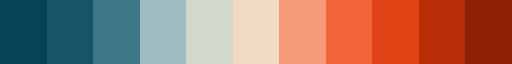

In [10]:
cmap_clusters = mcolors.LinearSegmentedColormap.from_list(
        f"white_to_test",
        ["#064455", "#1F6173", "#BED6D6", "#F1DBC3", "#F77044", "#D8370A", "#8D2002"],
        N=11
    )
cmap_clusters

In [11]:
year_list_10y = np.arange(2023, 1980, -5)
year_list_10y_rev = year_list_10y[::-1]
# year_list_10y = np.arange(2023, 2002, -2)

In [12]:
np.mean(np.array(res._ari_score_mean))

np.float64(0.9111297935851874)

In [13]:
pd.DataFrame(res._ari_score_mean, index=res._silhouette_score.index).mean()

0    0.91113
dtype: float64

In [14]:
np.min(np.array(res._modularity))

np.float64(0.19294395125626496)

In [15]:
res._silhouette_score.min()

score    0.220338
dtype: float64

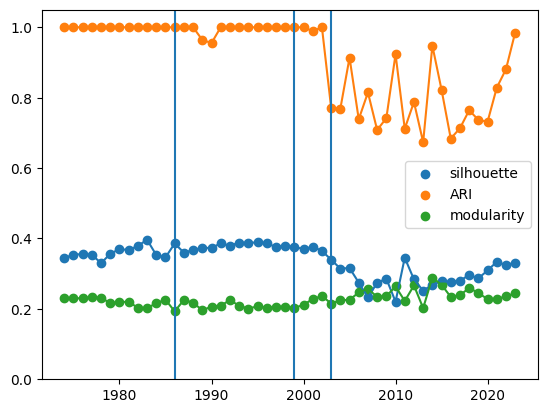

In [16]:
plt.plot(res._silhouette_score)
plt.scatter(res._year_list, res._silhouette_score, label="silhouette")
plt.plot(res._year_list, res._ari_score_mean)
plt.scatter(res._year_list, res._ari_score_mean, label="ARI")
plt.plot(res._year_list, res._modularity)
plt.scatter(res._year_list, res._modularity, label="modularity")
plt.legend()
plt.axvline(1986)
plt.axvline(2003)
plt.axvline(1999)
plt.ylim(0, 1.05)
plt.show()

In [17]:
cluster_list = res._df_mapping.dynamic_cluster.sort_values().drop_duplicates().to_list()

In [18]:
# res._df_mapping.query("(year in @year_list_10y)").to_csv("df_mapping_art.csv", index=False)

In [19]:
df_tmp = (
    res._df_mapping.query("(year in @year_list_10y)")
    .groupby(["dynamic_cluster", "year"], as_index=False).country.nunique()
    .sort_values(["year", "dynamic_cluster"], ascending=[False, True])
    .assign(
        # total_countries=lambda df: df.groupby("year").country.transform("sum"),
        country_share=lambda df: df.country / 195
    )
    .reset_index(drop=True)
)

In [20]:
x_array = np.full(len(df_tmp), np.nan)
y_array = np.full(len(df_tmp), np.nan)
height_array = np.full(len(df_tmp), np.nan)
width_array = np.full(len(df_tmp), np.nan)
color_array = np.full(len(df_tmp), np.nan, dtype=object)
country_array = np.full(len(df_tmp), np.nan, dtype=object)
country_cluster_array = np.full(len(df_tmp), np.nan, dtype=object)

domain_list = ["Physical Sciences", "Health Sciences", "Social Sciences", "Life Sciences"]

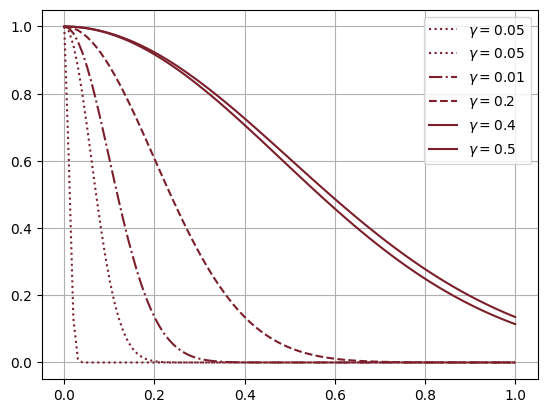

In [21]:
x = np.linspace(0, 1, 100)

plt.plot(x, np.exp(- x ** 2 / (2 * 0.01**2)), color="#7A1F2B", linestyle=":", label=r"$\gamma = 0.05$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.06**2)), color="#7A1F2B", linestyle=":", label=r"$\gamma = 0.05$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.1**2)), color="#7A1F2B", linestyle="-.", label=r"$\gamma = 0.01$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.2**2)), color="#7A1F2B", linestyle="--", label=r"$\gamma = 0.2$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.48**2)), color="#7A1F2B", label=r"$\gamma = 0.4$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.5**2)), color="#7A1F2B", label=r"$\gamma = 0.5$")

plt.legend()
plt.grid()

In [22]:
color_dict = {
    "individual": {
        -1: "#9D9D9D",
        # 0: "#2a7f8f",
        1: "#264653ff",
        5: "#fef2da",
        4: "#E0929C",
        6: "#7A1F2B",
        7: "#ffe4ea",
        # 7:"#f4a261ff",
        0:"#472025",
    },
}

In [23]:
# color_dict = {
#     "individual": {
#         -1: "#9D9D9D",
#         0: "#2a7f8f",
#         1: "#264653ff",
#         # 2: "#528260",
#         # 3: "#6a4b82",
#         5: "#fef2da",
#         6: "#e9c46aff",
#         4:"#f4a261ff",
#         7:"#e76f51ff",
#         # 8: "black",
#         # 9: "red",
#     },
#     "collaborative": {
#         -1: "#9D9D9D",
#         6: "#155567",
#         1: "#3f7887",
#         5: "#9ebfc2",
#         2: "#d2d8ce",
#         3: "#f1dbc3",
#         4: "#f59b77",
#         7:"#f16538",
#         0:"#D8370A"
#     }
# }
color_dict_tmp = color_dict[mode]

In [24]:
# clusters = list(df_tmp.dynamic_cluster.unique())

In [25]:
# cluster_color_dict = {
#     cluster: mcolors.to_hex(cmap(i))
#     for i, cluster in enumerate(cluster_list)
# }

In [34]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    name="test",
    colors=[
        (0, "white"),
        (0.4, "#E0929C"),
        (0.8, "#7A1F2B"),
        (1, "#472025")
    ]
)

clusters = list(df_tmp.dynamic_cluster.unique())

colors = cmap(np.linspace(0.15, 1, len(clusters)))

color_dict_tmp = dict(zip(clusters, colors))

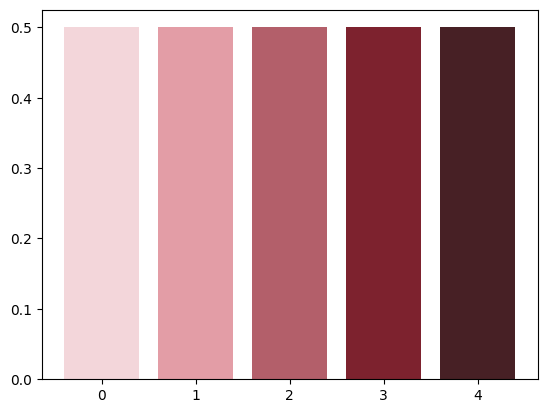

In [ ]:
for i in range(len(color_dict_tmp.keys())):
    plt.bar(i, 0.5, color=colors[i])

In [400]:
color_dict = {
    "individual": {
        -1: "#9D9D9D",
        # 0: "#2a7f8f",
        # 0: "#264653ff",
        0: "#203B47",
        # 0: "#204728",
        # 0: "#1F7A66",
        # 1: colors[2],
        1: colors[2],
        3: colors[1],
        4: colors[3],
        # 5: colors[4],
        5: "#93A6AD",
        # 5: "#7B9C82",
    },
}
# "#264653ff"

In [401]:
color_dict_tmp = color_dict["individual"]

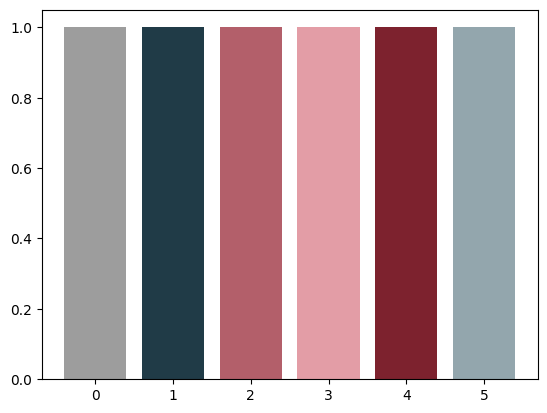

In [402]:
for i in range(len(color_dict_tmp.keys())):
    plt.bar(i, 1, color=color_dict_tmp[list(color_dict_tmp.keys())[i]])

In [403]:
["#f3d6da", "#e39da6", "#b35f6a", "#7d222e", "#7A1F2B" "#472025"]

['#f3d6da', '#e39da6', '#b35f6a', '#7d222e', '#7A1F2B#472025']

In [404]:
color_dict_tmp.keys()

dict_keys([-1, 0, 1, 3, 4, 5])

In [405]:
mcolors.to_hex(color_dict_tmp[1])

'#b35f6a'

In [406]:
print(color_dict_tmp)

{-1: '#9D9D9D', 0: '#203B47', 1: array([0.70196078, 0.37358708, 0.41626298, 1.        ]), 3: array([0.89034987, 0.61445598, 0.64982699, 1.        ]), 4: array([0.49019608, 0.13483276, 0.1816609 , 1.        ]), 5: '#93A6AD'}


In [407]:
total_share = df_tmp.query("year == 2023").country_share.sum()
width = 0.3

array_idx = 0
next_year_dict = {}
for i, year_loop in enumerate(year_list_10y):
    cluster_list_year = df_tmp.query("year == @year_loop").dynamic_cluster.to_list()
    country_share_list = df_tmp.query("year == @year_loop").country_share.to_list()
    n_clusters = len(cluster_list_year)
    share_year = df_tmp.query("year == @year_loop").country_share.sum()
    # vert_space = (total_share - share_year) / (n_clusters + 1)
    vert_space = 0

    vert_coord = 0
    for j in range(n_clusters):
        # print(year_loop, cluster_list_year[j], country_share_list[j])
        x_array[array_idx] = len(year_list_10y) - i - width
        y_array[array_idx] = vert_coord + vert_space
        height_array[array_idx] = country_share_list[j]
        width_array[array_idx] = width  # width of the bar (10 years)
        # color_array[array_idx] = cluster_color_dict[j]
        color_array[array_idx] = color_dict_tmp[cluster_list_year[j]]
        vert_coord += country_share_list[j] + vert_space
        array_idx += 1

rectangles = list(tuple(zip(x_array, y_array, width_array, height_array)))
# rectangles_ps = list(tuple(zip(x_array_ps, y_array_ps, width_array_ps, height_array_ps)))

In [408]:
prev_y1 = {}
for k, year_loop in enumerate(year_list_10y[1:]):
    next_year_dict = {}
    year_next = year_list_10y[k]
    if k < len(year_list_10y) - 3:
        year_prev = year_list_10y[k+2]
        # year_prev = None
        # year_prev_prev = year_list_10y[k+3]
        year_prev_prev = None
    elif k < len(year_list_10y) - 2:
        year_prev = year_list_10y[k+2]
        # year_prev = None
        year_prev_prev = None
    else:
        year_prev = None
        year_prev_prev = None
    cluster_list_year = df_tmp.query("year == @year_loop").dynamic_cluster.to_list()
    
    for i in range(len(cluster_list_year)):
        cluster_loop = cluster_list_year[i]
        if year_prev_prev is not None:
            df_cluster_year = (
                res._df_mapping.query("year == @year_loop")
                .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
                .merge(res._df_mapping.query("year == @year_prev"), on="country", how="left", suffixes=["", "_prev"])
                .merge(res._df_mapping.query("year == @year_prev_prev"), on="country", how="left", suffixes=["_cur", "_prev_prev"])
                .query("dynamic_cluster_cur == @cluster_loop")
                .sort_values(["dynamic_cluster_prev_prev", "dynamic_cluster_prev", "dynamic_cluster_next"])
                # .sort_values(["cluster_prev", "cluster_next"])
            )
        elif year_prev is not None:
            df_cluster_year = (
                res._df_mapping.query("year == @year_loop")
                .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
                .merge(res._df_mapping.query("year == @year_prev"), on="country", how="left", suffixes=["_cur", "_prev"])
                .query("dynamic_cluster_cur == @cluster_loop")
                .sort_values(["dynamic_cluster_prev", "dynamic_cluster_next"])
                # .sort_values(["cluster_next"])
            )
        else:
            df_cluster_year = (
                res._df_mapping.query("year == @year_loop")
                .merge(res._df_mapping.query("year == @year_next"), on="country", how="left", suffixes=["_cur", "_next"])
                .query("dynamic_cluster_cur == @cluster_loop")
                .sort_values(["dynamic_cluster_next"])
            )
        # display(df_cluster_year)
        n_countries = len(df_cluster_year)
        cur_cluster_idx = df_tmp.query("(year == @year_loop) and (dynamic_cluster == @cluster_loop)").index[0]
        # print(cur_cluster_idx)
        country_step = height_array[cur_cluster_idx] / n_countries

        x1_array = np.full(n_countries, np.nan)
        y1_array = np.full(n_countries, np.nan)
        x2_array = np.full(n_countries, np.nan)
        y2_array = np.full(n_countries, np.nan)
        c_array = np.full(n_countries, np.nan, dtype=object)

        x1_cluster_array = np.full(n_countries, np.nan)
        y1_cluster_array = np.full(n_countries, np.nan)
        x2_cluster_array = np.full(n_countries, np.nan)
        y2_cluster_array = np.full(n_countries, np.nan)
        c_cluster_array = np.full(n_countries, np.nan, dtype=object)

        next_year_list = df_cluster_year.dynamic_cluster_next.dropna().unique().tolist()
        for next_cluster in next_year_list:
            if next_cluster not in next_year_dict:
                next_cluster_idx = df_tmp.query("(year == @year_next) and (dynamic_cluster == @next_cluster)").index[0]
                next_year_dict[next_cluster] = y_array[next_cluster_idx]
       
        y_cur = y_array[cur_cluster_idx]
        for j, country in enumerate(df_cluster_year.country):
            next_cluster = df_cluster_year.query("country == @country").dynamic_cluster_next.values[0]
            y1_array[j] = y_cur
            if np.isnan(next_cluster):
                continue
            y2_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            x1_array[j] = len(year_list_10y) - k - 1
            x2_array[j] = len(year_list_10y) - k - width
            c_array[j] = country

            y1_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            y2_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            x1_cluster_array[j] = len(year_list_10y) - k - width
            x2_cluster_array[j] = len(year_list_10y) - k
            c_cluster_array[j] = country

            prev_y1[country] = y_cur

            y_cur += country_step
            next_year_dict[next_cluster] += country_step

        country_array[cur_cluster_idx] = list(tuple(zip(x1_array, y1_array, x2_array, y2_array, c_array)))
        country_cluster_array[cur_cluster_idx] = list(tuple(zip(x1_cluster_array, y1_cluster_array, x2_cluster_array, y2_cluster_array, c_cluster_array)))

    # print(k, year_loop, year_next)

In [409]:
def draw_flow(ax, x0, y0, x1, y1, curvature=0.5, color='grey', alpha=0.5, zorder=0):
    from matplotlib.path import Path
    import matplotlib.patches as patches

    dx = x1 - x0

    control1 = (x0 + curvature * dx, y0)
    control2 = (x1 - curvature * dx, y1)

    path = Path(
        [(x0, y0), control1, control2, (x1, y1)],
        [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    )

    patch = patches.PathPatch(
        path,
        facecolor='none',
        edgecolor=color,
        linewidth=1.5,
        alpha=alpha,
        zorder=zorder
    )

    ax.add_patch(patch)

In [410]:
import geopandas as gpd
from shapely import wkt

# url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file("world.csv")
world["geometry"] = world["geometry"].apply(wkt.loads)

world = gpd.GeoDataFrame(world, geometry="geometry", crs="EPSG:4326")
# world = world[world['CONTINENT'] != 'Antarctica']

# # Convert BOTH to same CRS
# world = world.to_crs(epsg=4326)
# world = pd.read_csv("world.csv")

In [411]:
df_prob_full = (
    df_prob.xs(mode, level=2)
    .merge(res._df_mapping[["country", "year", "dynamic_cluster"]], left_index=True, right_on=["country", "year"], how="right")
    .set_index(["country", "year", "dynamic_cluster"])
)

In [412]:
sc = rm.SomeClass(np.log(df_prob_full.replace({0: np.nan})))
sc.get_metric(level_agg = 2, level_norm = 1)
df_metric = sc._df_metric
sc.get_pos_metric(0)
sc.get_pos_metric_norm()

In [413]:
sc._df_metric.xs(2023)

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,1212,2104,1409,2922,1410,2402,2714,1200,2718,3002
dynamic_cluster,,,,,,,,,,,,,,,,,,,,,
4,7.299575,3.944649,0.701899,1.930367,1.150613,3.163452,3.232988,4.585420,1.555365,-0.668548,...,5.666380,1.884315,2.512887,-3.337644,6.764934,-1.072567,-6.083247,6.729739,-5.238939,8.251193
5,-6.239684,-2.411482,-0.434226,-0.779264,-0.781770,-2.639223,-1.832361,-3.477773,-0.811012,0.610050,...,-3.323939,-0.655024,-0.873527,0.290057,-4.703240,0.416709,1.585989,-4.386348,1.233686,-8.604816


In [414]:
sf_list = df_subfield.subfield_id.to_list()
year = 2023
df = sc._df_metric.xs(year)[sf_list]

In [415]:
position_list = (
    df_subfield
    .reset_index(drop=True)
    .reset_index(names=["position"])
    .groupby("domain_id", as_index=False).first()
    .sort_values(["domain_id", "field_id"], ascending=[True, True])
    .position.to_list()
)

position_field_list = (
    df_subfield
    .reset_index(drop=True)
    .reset_index(names=["position"])
    .groupby("field_id", as_index=False).first()
    .sort_values(["domain_id", "field_id"], ascending=[True, True])
    .position.to_list()
)

names_field_list = (
    df_subfield
    .reset_index(drop=True)
    .reset_index(names=["position"])
    .groupby("field_id", as_index=False).first()
    .sort_values(["domain_id", "field_id"], ascending=[True, True])
    .field_name.to_list()
)

In [416]:
r_max = 10
r_min = r_max * 2
coef = 3

In [417]:
field_dict = {
    "Environmental Science": "Environ. Sc.",
    "Physics and Astronomy": "Phys. & Astron.",
    "Earth and Planetary Sciences": "Earth & Planet.",
    "Economics, Econometrics and Finance": "Econ. & Finance         ",
    "Pharmacology, Toxicology and Pharmaceutics": "        Pharma. & Toxicology",
    "Veterinary": "                  Veterinary",
    "Business, Management and Accounting": "Business & Account.",
    "Immunology and Microbiology": "Immun. & Microbio.",
    "Biochemistry, Genetics and Molecular Biology": "Biochem. & Genetics",
    "Arts and Humanities": "Arts & Humanities",
    "Agricultural and Biological Sciences": "Agricult. & Bio. Sc.",
    "Dentistry": "   Dentistry",
    "Nursing": "  Nursing"
}

In [418]:
def draw_polar(ax, df, year, r_max, color_dict_tmp):

    r_min = r_max * 2
    coef = 3

    n = df.shape[1]
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)

    for i, row in df.iterrows():
        r = row.values

        theta_closed = np.append(theta, theta[0])
        r_closed = np.append(r, r[0])

        ax.plot(theta_closed, r_closed, color=color_dict_tmp[i], alpha=1, linewidth=2.5)

        ax.fill_between(theta_closed, 0, np.clip(r_closed, 0, None),
                        alpha=0.3, color=color_dict_tmp[i])

        ax.fill_between(theta_closed, 0, np.clip(r_closed, None, 0),
                        alpha=0.3, color=color_dict_tmp[i])

    ax.set_ylim(-r_min, coef * r_max)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines['polar'].set_visible(False)
    # ax.set_title(str(year), fontsize=20)


    # example angles
    n = 252
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)

    # --- grey zones (example: 3 segments) ---
    zones = [
        (0, np.pi/3),
        (np.pi, 4*np.pi/3)
    ]
    zones = [
        (position_list[0] * 2*np.pi/n, position_list[1] * 2*np.pi/n),
        (position_list[1] * 2*np.pi/n, position_list[2] * 2*np.pi/n),
        (position_list[2] * 2*np.pi/n, position_list[3] * 2*np.pi/n),
        (position_list[3] * 2*np.pi/n, 2*np.pi)
    ]      

    zones_colors = ['#f1efe1', '#414357', '#d1836f', '#86ac9a']

    theta = np.linspace(0, 2*np.pi, df.shape[1], endpoint=False)


    for start, end in zones:
        ax.bar(
            x=(start + end) / 2,      # center angle
            height=0.2*r_max,
            width=(end - start),
            # top=20,
            bottom=r_max,
            color=zones_colors[zones.index((start, end))],
            alpha=1,
            edgecolor=None,
            # zorder=0
        )
        ax.plot([start, start], [-r_min, r_max+2], color="black", alpha=1, linewidth=1, zorder=0)
        # ax.plot([end, end], [-r_min, r_max+2], color="black", alpha=1, linewidth=1, zorder=0)

    theta = np.linspace(0, 2*np.pi, 500)

    ax.plot(
        theta,
        np.zeros_like(theta),
        color='black',
        linewidth=1,
        zorder=2
    )

    ax.plot(
        theta,
        r_max* np.ones_like(theta),
        color='black',
        linewidth=1,
        zorder=2
    )

    ax.grid(False)

    for i, pos in enumerate(position_field_list):
        a = pos * 2*np.pi/n
        if names_field_list[i] == "Veterinary":
            ax.plot([a, a], [-r_min, 3.5 * r_max],
                    color="black", alpha=1, linewidth=1, zorder=0)
        else:
            ax.plot([a, a], [-r_min, coef * r_max],
                    color="black", alpha=1, linewidth=1, zorder=0)
        # print(i, a / np.pi * 180)
        if (a / np.pi * 180) <= 90 or (a / np.pi * 180) >= 270:
            ha = 'left'
            va = "bottom"
            angle = a + 0.01
            rotation = angle / np.pi * 180  
        else:
            ha = 'right'
            va = "top"
            angle = a + 0.01
            rotation = (a + 0.025) / np.pi * 180 + 180
        if names_field_list[i] in field_dict.keys():
            test_text = field_dict[names_field_list[i]].split(" ")
        else:
            test_text = names_field_list[i].split(" ")
        if (len(test_text) > 3) and  not (names_field_list[i] in field_dict.keys()):
            test_text = " ".join(test_text[:2]) + "\n" + " ".join(test_text[2:])
        else:
            test_text = " ".join(test_text)
        ax.text(angle, r_max+0.3*r_max, test_text, ha=ha, va=va, rotation=rotation, rotation_mode='anchor', fontsize=20)

    ax.set_ylim(-r_min, coef * r_max)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines['polar'].set_visible(False)

    # plt.savefig(f"spec_art_{year}_no_fields.svg",format="svg",
    #     transparent=True,)
    _ = ax.text(np.pi / 2, 5*r_max, year, va="center", ha="center", fontsize=24, fontweight="bold")

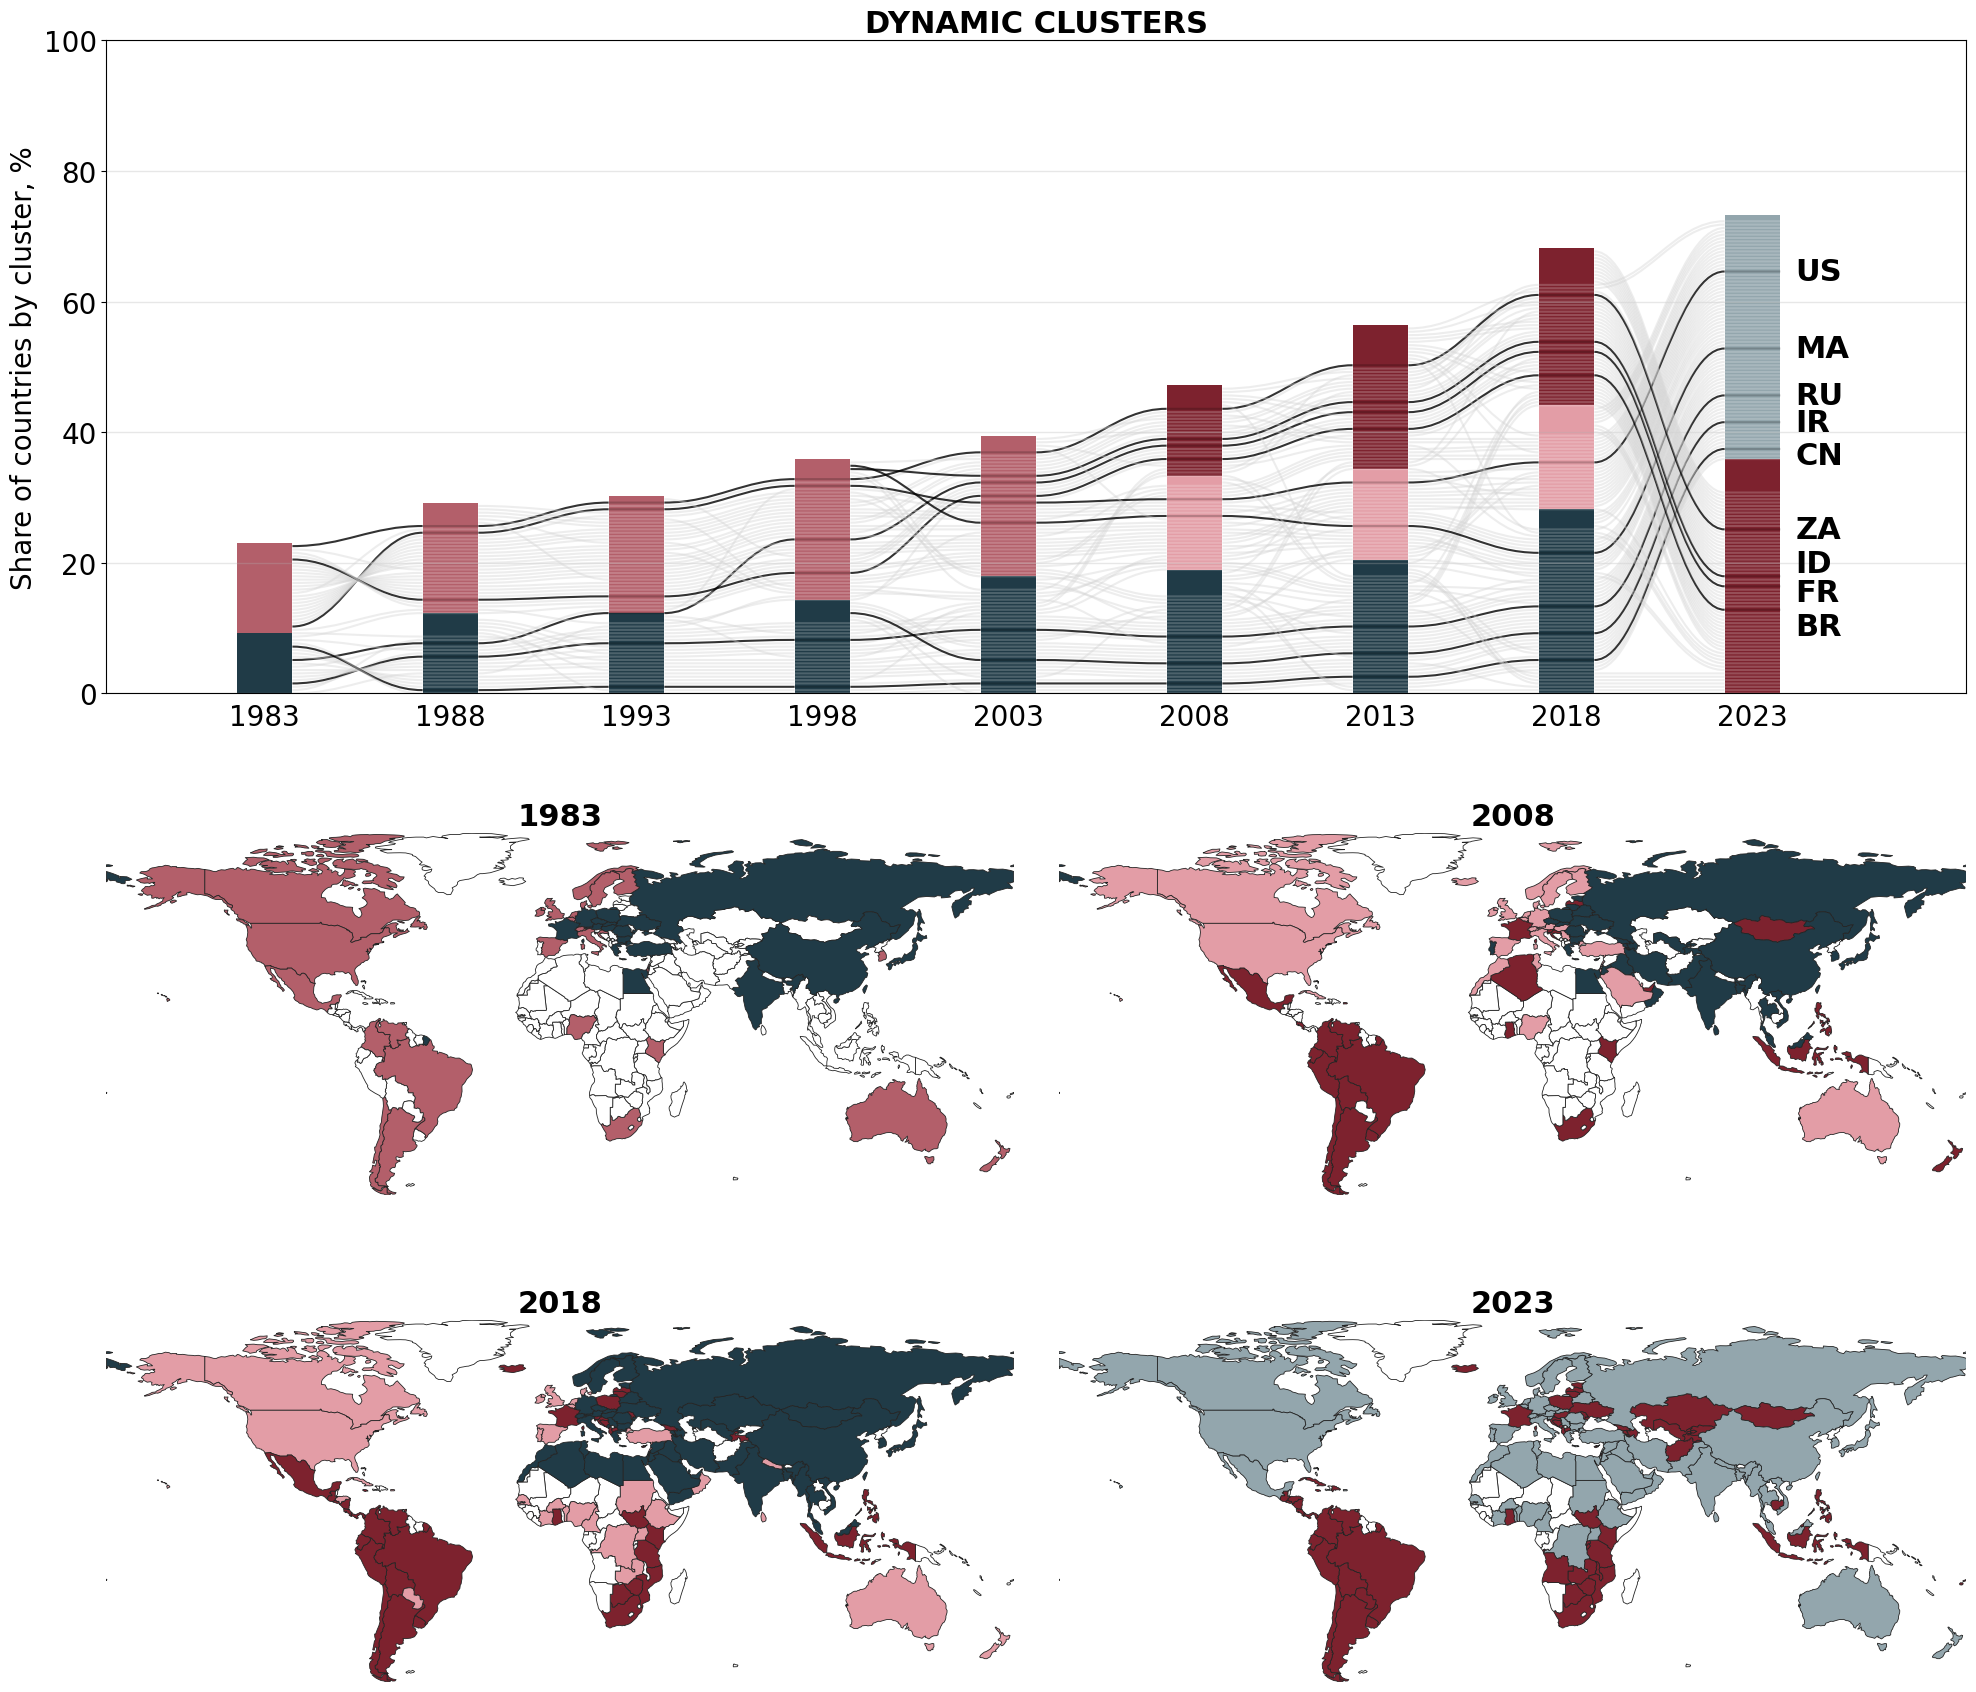

In [422]:
fig = plt.figure(figsize=(24, 22))

base_fontsize=20

outer = fig.add_gridspec(
    4, 2,
    height_ratios=[1.4, 0.1, 1, 1],
    hspace=0.05,
    wspace=0.05
)

# ax_gap = fig.add_subplot(outer[3, :])
# ax_gap.set_axis_off()
ax_big = fig.add_subplot(outer[0, :])   # 👈 spans both columns
ax_big.set_title("DYNAMIC CLUSTERS", fontsize=base_fontsize+2, fontweight="bold")

to_print_list = ["CN", "RU", "BR", "ZA", "US", "FR", "MA", "IR", "ID"]
printed_list = []

for i, (x, y, w, h) in enumerate(rectangles):
    rect = patches.Rectangle(
        (x, y), w, h,
        edgecolor=None,
        facecolor=color_array[rectangles.index((x, y, w, h))],
        zorder=1
    )
    ax_big.add_patch(rect)
    
    if not isinstance(country_array[i], list):
        continue
    for (x0, y0, x1, y1, c) in country_array[i]:
        if c in to_print_list:
            draw_flow(ax_big, x0, y0, x1, y1, curvature=0.4, color="black", alpha=0.8, zorder=2)
        else:
            draw_flow(ax_big, x0, y0, x1, y1, curvature=0.4, color="lightgrey", alpha=0.4, zorder=2)

    for (x0, y0, x1, y1, c) in country_cluster_array[i]:
        if c in to_print_list:
            draw_flow(ax_big, x0, y0, x1, y1, curvature=0.4, color="black", alpha=0.2, zorder=2)
            if c not in printed_list:
                if c == "RU":
                    y1 += 0
                if c == "ZA":
                    y1 += 0
                if c == "ID":
                    y1 += 0.02
                if c == "FR":
                    y1 -= 0.01
                if c == "CN":
                    y1 -= 0.01
                if c == "BR":
                    y1 -= 0.025
                ax_big.text(x1+0.08, y1, c, ha='left', va='center', fontdict={"size": base_fontsize+2, "weight": "bold"})
                printed_list.append(c)
        else:
            draw_flow(ax_big, x0, y0, x1, y1, curvature=0.4, color="white", alpha=0.2, zorder=2)

ax_big.set_ylabel("Share of countries by cluster, %", fontsize= base_fontsize)
ax_big.set_xlim(0, 10)
ax_big.set_ylim(0, 1)

ax_big.set_xticks([])
ax_big.set_yticks(np.linspace(0, 1, 6), labels=np.linspace(0, 100, 6, dtype=int), fontdict={"size": base_fontsize})

ax_big.tick_params(axis='x', color='none')


ax_big.grid(axis='y', linestyle='-', linewidth=1, alpha=0.3, zorder=0)

x = np.arange(len(year_list_10y))+1-width/2

ax_big.set_xticks(x)
_= ax_big.set_xticklabels(year_list_10y_rev, fontdict={"size": base_fontsize})
ax_big.set_aspect('auto')

ax_left = fig.add_subplot(outer[2, 0])
ax_right = fig.add_subplot(outer[2, 1])

year = 1983
# --- 4. Merge with world map ---
world_ = world.merge(
    res._df_mapping.query("year == @year").merge(df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Map cluster → color ---
world_["color"] = world_["dynamic_cluster"].map(color_dict_tmp)

# fallback for missing
world_["color"] = world_["color"].fillna("white")

world_.plot(
    color=world_["color"],
    edgecolor="#242424",
    linewidth=0.6,
    ax=ax_left
)
# ax_right.set_aspect('auto')
ax_left.set_axis_off()
ax_left.margins(0)
ax_left.set_title(year, fontsize=base_fontsize+2, fontweight="bold")

year = 2008
# --- 4. Merge with world map ---
world_ = world.merge(
    res._df_mapping.query("year == @year").merge(df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Map cluster → color ---
world_["color"] = world_["dynamic_cluster"].map(color_dict_tmp)

# fallback for missing
world_["color"] = world_["color"].fillna("white")

world_.plot(
    color=world_["color"],
    edgecolor="#242424",
    linewidth=0.6,
    ax=ax_right
)
# ax_right.set_aspect('auto')
ax_right.set_axis_off()
ax_right.margins(0)
ax_left.margins(0)
ax_right.set_title(year, fontsize=base_fontsize+2, fontweight="bold")

ax_left = fig.add_subplot(outer[3, 0])
ax_right = fig.add_subplot(outer[3, 1])



year = 2018
# --- 4. Merge with world map ---
world_ = world.merge(
    res._df_mapping.query("year == @year").merge(df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Map cluster → color ---
world_["color"] = world_["dynamic_cluster"].map(color_dict_tmp)

# fallback for missing
world_["color"] = world_["color"].fillna("white")


world_.plot(
    color=world_["color"],
    edgecolor="#242424",
    linewidth=0.6,
    ax=ax_left
)
ax_left.set_title(year, fontsize=base_fontsize+2, fontweight="bold")
ax_left.set_axis_off()
# ax_left.set_aspect('auto')

ax_left.set_title(year, fontsize=base_fontsize+2, fontweight="bold")

year = 2023
# --- 4. Merge with world map ---
world_ = world.merge(
    res._df_mapping.query("year == @year").merge(df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Map cluster → color ---
world_["color"] = world_["dynamic_cluster"].map(color_dict_tmp)

# fallback for missing
world_["color"] = world_["color"].fillna("white")

world_.plot(
    color=world_["color"],
    edgecolor="#242424",
    linewidth=0.6,
    ax=ax_right
)
# ax_right.set_aspect('auto')
ax_right.set_axis_off()
ax_right.set_title(year, fontsize=base_fontsize+2, fontweight="bold")
ax_right.margins(0)
ax_left.margins(0)

# ax_left = fig.add_subplot(outer[4, 0], projection = "polar",)
# ax_right = fig.add_subplot(outer[4, 1], projection = "polar")
# draw_polar(ax_left, sc._df_metric.xs(1983)[sf_list], 1983, 10, color_dict_tmp)
# draw_polar(ax_right, sc._df_metric.xs(2023)[sf_list], 2023, 10, color_dict_tmp)
# ax_right.margins(0)
# ax_left.margins(0)
# ax_right.set_aspect('auto')

# fig.show() 
fig.savefig(f"../images/dynamic_clusters_v4.jpg", dpi=1000, bbox_inches='tight')

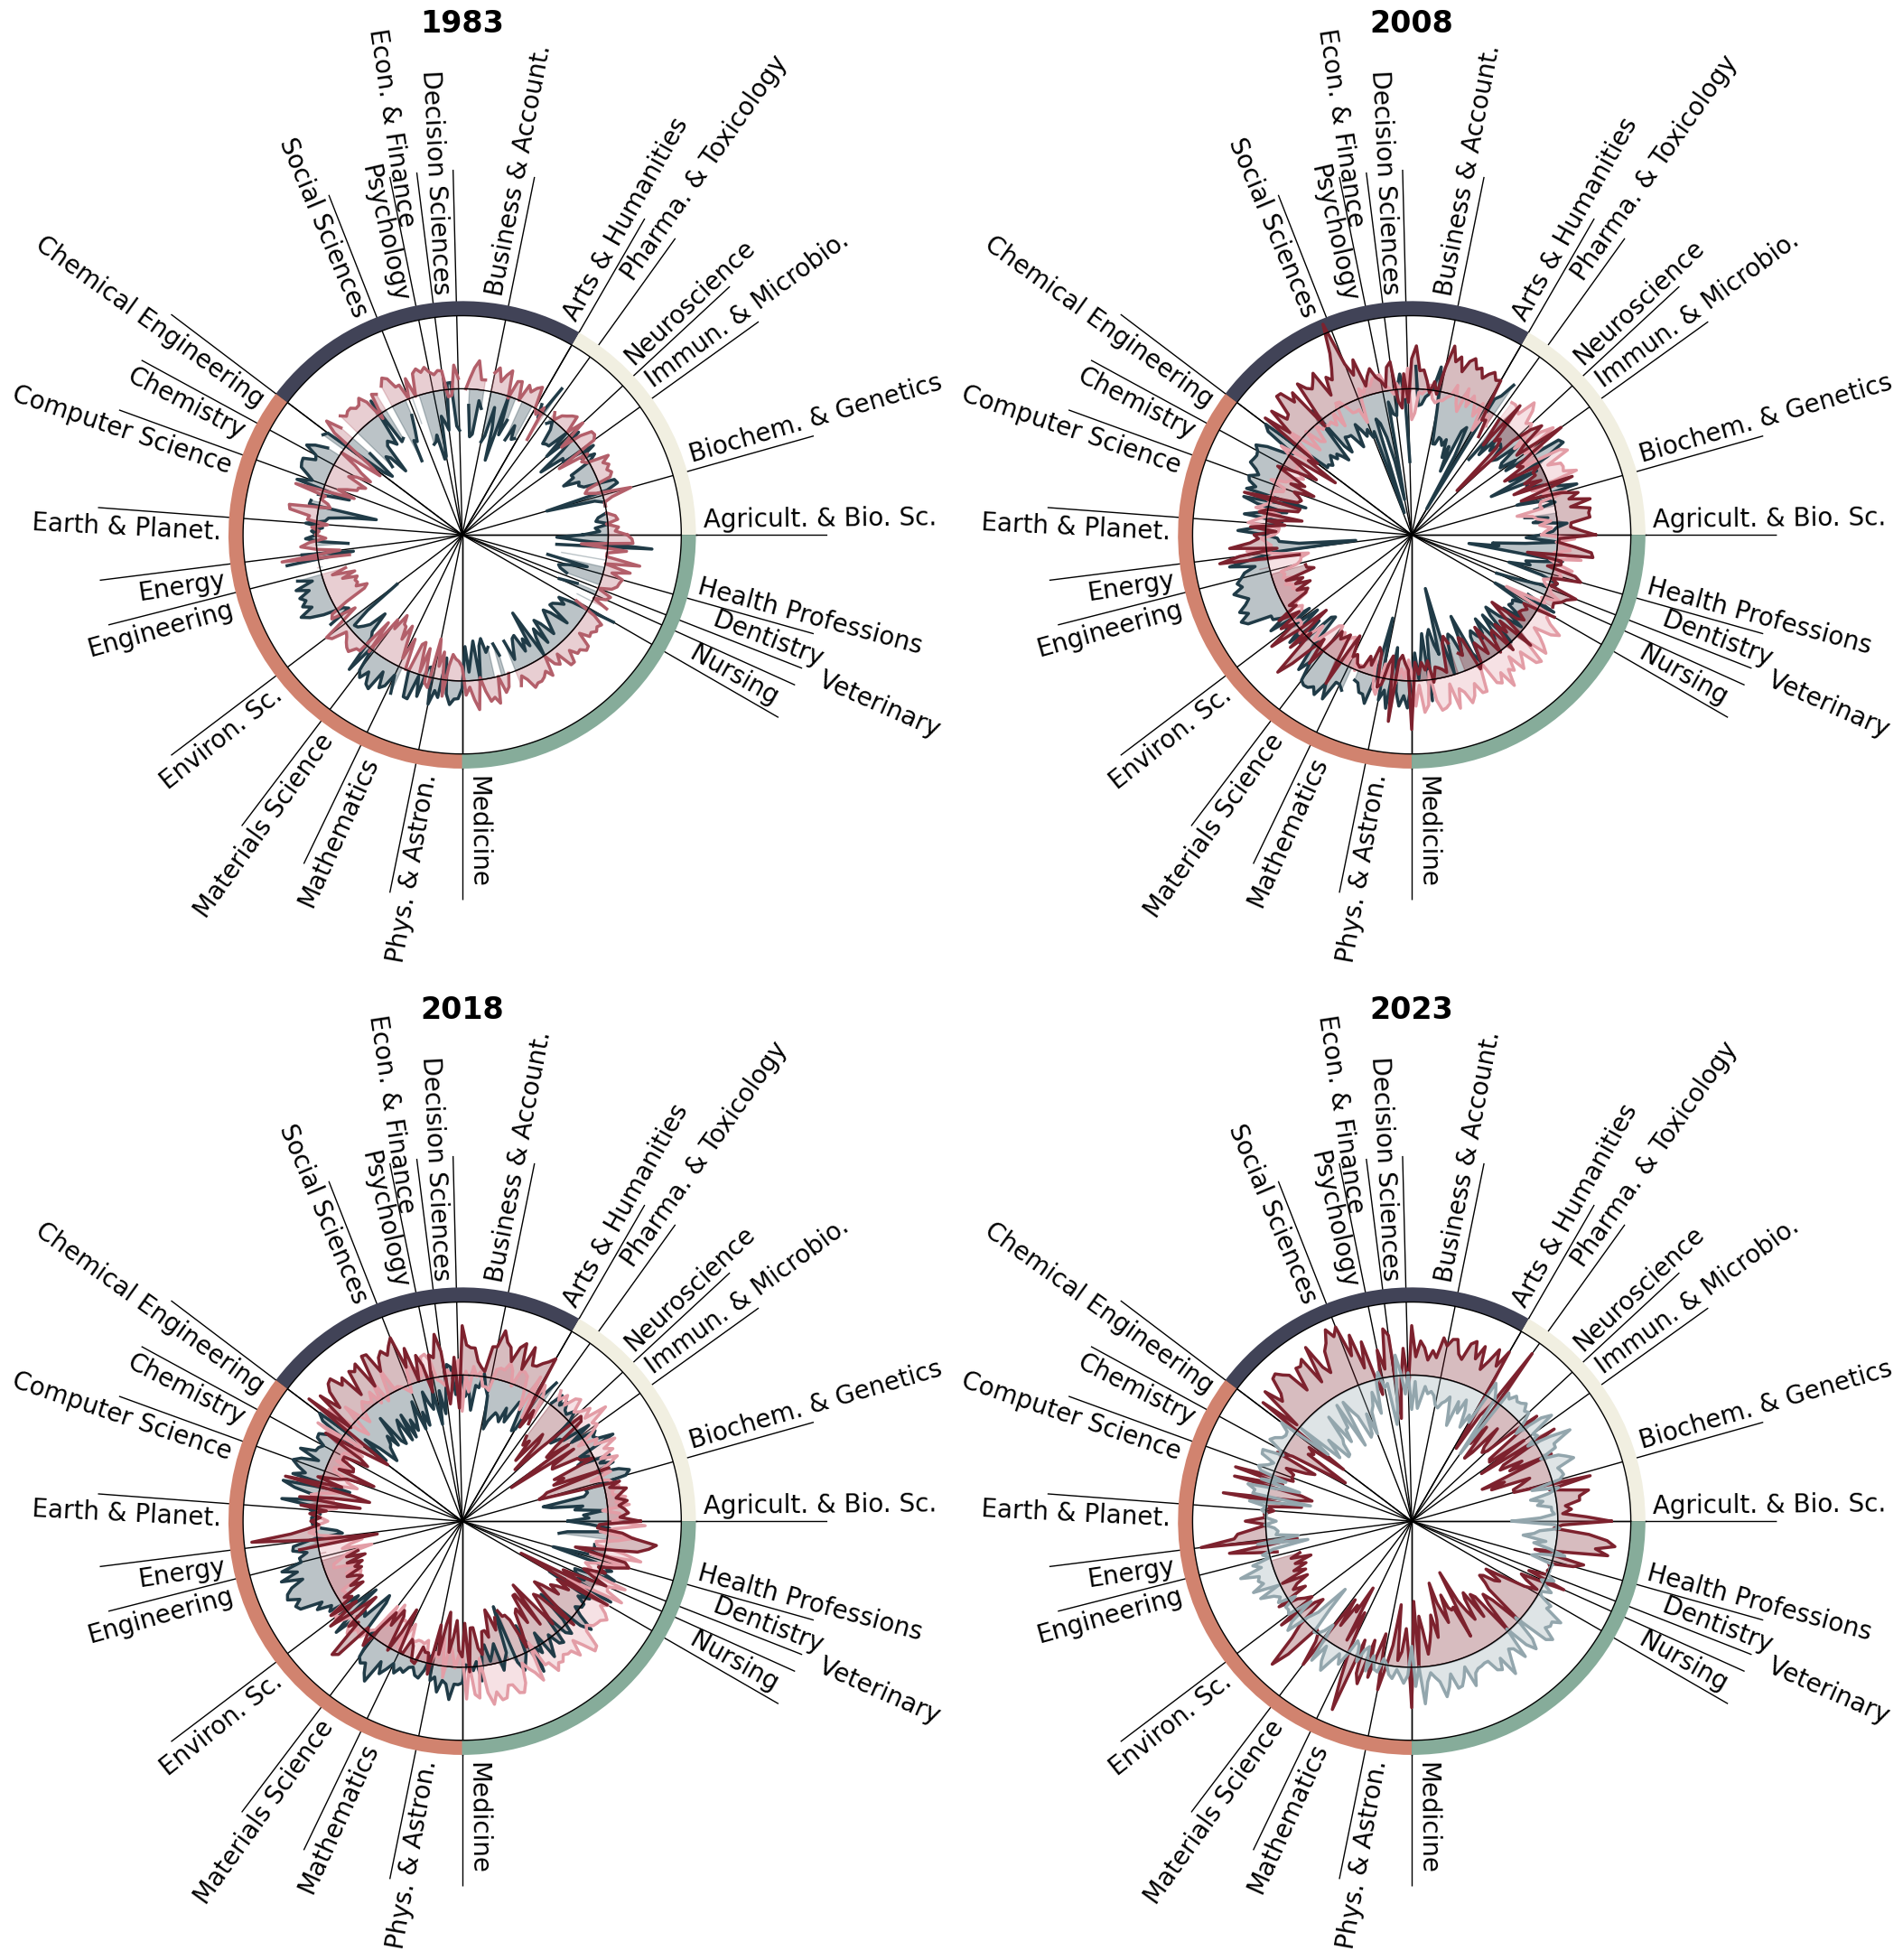

In [423]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
    2, 2,
    subplot_kw={'projection': 'polar'},
    figsize=(24, 26)
)

draw_polar(ax1, sc._df_metric.xs(1983)[sf_list], 1983, 10, color_dict_tmp)
draw_polar(ax2, sc._df_metric.xs(2008)[sf_list], 2008, 10, color_dict_tmp)
draw_polar(ax3, sc._df_metric.xs(2018)[sf_list], 2018, 10, color_dict_tmp)
draw_polar(ax4, sc._df_metric.xs(2023)[sf_list], 2023, 10, color_dict_tmp)
fig.subplots_adjust(wspace=0.3)
fig.savefig(f"../images/spec_all_v3.jpg", dpi=1000, bbox_inches='tight')